In [1]:
import pandas as pd
import numpy as np
import sklearn as sk

#My own module for SVM analysis
import main_funcs

In [2]:
lines = ["Bima1", "Kolf2", "Kolf3", "Podx1", "Qolg1", "Wibj2"]
lines_gene = ["geneid", "Bima1", "Kolf2", "Kolf3", "Podx1", "Qolg1", "Wibj2"]

In [3]:
DE_genes=pd.read_csv("DEGs_TPMs.csv", index_col=0)
DE_genes6lines=pd.read_csv("DE_hiPSC6.csv")
DE_genes6=DE_genes[DE_genes.geneid.isin(DE_genes6lines.geneid)]
DE_genes6=DE_genes6[lines_gene]
DE_genes6=DE_genes6.reset_index(drop=True)
DE_genes6

,geneid,Bima1,Kolf2,Kolf3,Podx1,Qolg1,Wibj2
0,ENSG00000002587,0.056327,0.974623,1.250235,0.889320,0.860547,1.401540
1,ENSG00000003436,1.587506,0.287930,0.242709,0.617389,1.933951,2.891098
2,ENSG00000005421,1.084168,0.167938,0.370911,0.748666,1.696980,2.521149
3,ENSG00000012223,0.760768,1.696081,1.916088,0.062058,0.580911,1.443260
4,ENSG00000013588,0.460276,0.343586,0.509533,0.182050,0.494406,1.958777
...,...,...,...,...,...,...,...
120,ENSG00000277117,1.775971,2.106939,1.722862,0.224589,3.062859,3.035575
121,ENSG00000278318,13.963399,12.080258,7.331603,5.028199,9.353548,0.578283
122,ENSG00000278558,2.291848,0.569033,0.777804,0.677550,0.571363,5.428396
123,ENSG00000278662,0.842786,0.688875,0.924685,0.075595,2.223470,3.350317


In [4]:
#Script for predictive accuracy of the SVM pipeline without bootstrapping.
#For Supplementary Fig. 4D, run with different annotation files

epig_vars=['K4', 'K9', 'K27', 'ATAC']
accuracy=[]
tgts=[]
prob_preds=[]

#Seed initialisation for Kmeans
np.random.seed(24601)

#Load from file and preparing the data for the SVM
intensities_K4 = pd.read_csv('DEGs_scores/DE_genes_K4me3_geneSVM10.csv')
intensities_K4_tx = pd.read_csv('DEGs_scores/DE_genes_K4me3_tx_pm1kSVM10.csv')
intensities_K4_promoters = pd.read_csv('DEGs_scores/DE_genes_K4me3_prompm1kSVM10.csv')

intensities_K4_pm1k = np.maximum(intensities_K4_tx, intensities_K4_promoters)
intensities_K4 = np.maximum(intensities_K4, intensities_K4_pm1k)
intensities_K4 = pd.DataFrame(intensities_K4, columns=intensities_K4.columns, index=intensities_K4.index)
    
intensities_K9 = pd.read_csv('DEGs_scores/DE_genes_K9me3_geneSVM10.csv')
    
intensities_K27 = pd.read_csv('DEGs_scores/DE_genes_K27me3_geneSVM10.csv')
    
intensities_ATAC = pd.read_csv('DEGs_scores/DE_genes_ATAC_geneSVM10.csv')
intensities_ATAC_tx = pd.read_csv('DEGs_scores/DE_genes_ATAC_tx_pm1kSVM10.csv')
intensities_ATAC_promoters = pd.read_csv('DEGs_scores/DE_genes_ATAC_prompm1kSVM10.csv')

intensities_ATAC_pm1k = np.maximum(intensities_ATAC_tx, intensities_ATAC_promoters)
intensities_ATAC = np.maximum(intensities_ATAC, intensities_ATAC_pm1k)
intensities_ATAC = pd.DataFrame(intensities_ATAC, columns=intensities_ATAC.columns, index=intensities_ATAC.index)


In [5]:
from sklearn.metrics import auc

i=0

AUC_svm=np.zeros(len(lines))
for test_line in lines:
    filename="AUCs/"+test_line+"_svm_auc_6lines.csv"
    data=np.genfromtxt(filename, delimiter=",")
    AUC_svm[i]=auc(np.transpose(data)[0],np.transpose(data)[1])
    i+=1

AUC_svm

array([0.84148224, 0.85559089, 0.85956545, 0.7586478 , 0.83608491,
       0.8740677 ])

In [52]:
#Script for predictive accuracy of the SVM pipeline with bootstrapping. 
#Note that the scores files need to be already imported (see script without bootstrapping).

from sklearn.metrics import auc

epig_vars=['K4', 'K9', 'K27', 'ATAC']

n_boots=100 #Note that for the data presented in the manuscript the value used was 1000.
accuracy=np.zeros([6,n_boots])
aucs=np.zeros([6,n_boots])

#Seed initialisation for Bootstrap
np.random.seed(24601)

n_train=5 #9 datapoints in training set
#Cycle over all cell lines to test all of them from the other 9
tline=0
for test_line in lines:
    #Binarise transcription for the training data and assign a binarisation to the test data (ground truth).
    training_lines=lines.copy()
    training_lines.remove(test_line)
    for s in range(n_boots):
        #Bootstrap. Sample with replacement trining set.
        rvect=np.random.choice(5, 5, replace=True)
        all_same = (rvect == rvect[0]).all()
        if all_same==1: #I had withdrawn a sample which is all samples repeated (or all zeros). Either case, not good for training.
            rvect=np.random.choice(5, 5, replace=True)
           
        boots_lines=[training_lines[i] for i in rvect]
        i=0
        boots_cols=[None] * n_train
        for line in boots_lines:
            if boots_lines[0:i].count(line)>0:
                boots_cols[i]=boots_lines[i]+"_"+str(boots_lines[0:i].count(line))
            else:
                boots_cols[i]=boots_lines[i]
            i+=1
        DE_boots=pd.DataFrame(data=DE_genes6['geneid'])
        for l in range(n_train):
            DE_boots[boots_cols[l]]=DE_genes6[boots_lines[l]]
        DE_boots[test_line]=DE_genes6[test_line]
        
        #Exclude genes with all zeros in the training dataset.
        zero_genes=[]
        for gene in DE_boots['geneid']:
            if DE_boots[boots_cols][DE_boots.geneid==gene].sum(axis=1).values[0]==0:
                zero_genes.append(gene)
        DE_boots=DE_boots[~DE_boots.geneid.isin(zero_genes)]
        DE_boots=DE_boots.reset_index(drop=True)
        #Feed the bootstrapping sample
        DE_bin_train, test_ground_truth=main_funcs.binarize_test(DE_boots,boots_cols, test_line)

        vars = pd.DataFrame(columns=['geneid', 'line', 'K4', 'K9', 'K27', 'ATAC', 'expression'])
        for l in range(n_train):
            for gene in DE_bin_train['geneid']:
                vars.loc[len(vars)] = [gene, line, intensities_K4.loc[intensities_K4['geneid'] == gene, boots_lines[l]].values[0], 
                                       intensities_K9.loc[intensities_K9['geneid'] == gene, boots_lines[l]].values[0], 
                                       intensities_K27.loc[intensities_K27['geneid'] == gene, boots_lines[l]].values[0], 
                                       intensities_ATAC.loc[intensities_ATAC['geneid'] == gene, boots_lines[l]].values[0], 
                                       DE_bin_train.loc[DE_bin_train['geneid'] == gene, boots_cols[l] + '_binary'].values[0]]

        genes_test=pd.DataFrame(columns=['geneid', 'test_line', 'K4', 'K9', 'K27', 'ATAC'])
        for gene in DE_bin_train['geneid']:
            genes_test.loc[len(genes_test)] = [gene, test_line,
                                        intensities_K4.loc[intensities_K4['geneid'] == gene, test_line].values[0], 
                                        intensities_K9.loc[intensities_K9['geneid'] == gene, test_line].values[0], 
                                        intensities_K27.loc[intensities_K27['geneid'] == gene, test_line].values[0], 
                                        intensities_ATAC.loc[intensities_ATAC['geneid'] == gene, test_line].values[0]]
        #SVM for prediction
        probs_prediction, prediction=main_funcs.SVM_prediction(DE_bin_train['geneid'], vars, genes_test, epig_vars)
        #ROC curve 
        tgt=test_ground_truth.transcription.to_numpy(dtype=bool)
        fpr, tpr, thres=sk.metrics.roc_curve(tgt,probs_prediction)

        #General accuracy
        accuracy[tline,s]=sum(test_ground_truth.transcription.to_numpy(dtype=bool)==prediction)/len(DE_bin_train['geneid'])
        aucs[tline,s]=auc(fpr,tpr)
    tline+=1
    print(test_line)
    
np.savetxt('accuracy_svm_boots_100_6lines.csv', accuracy, delimiter=",")
np.savetxt('auc_svm_boots_100_6lines.csv', aucs, delimiter=",")

Bima1
Kolf2
Kolf3
Podx1
Qolg1
Wibj2


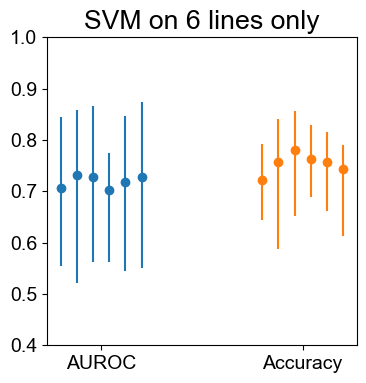

In [11]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rc
#Script to obtain Supplementary Fig. 5G

aucs=np.genfromtxt("auc_svm_boots_100_6lines.csv", delimiter=',')
aucs_log=np.genfromtxt("accuracy_svm_boots_100_6lines.csv", delimiter=',')

low=[]
high=[]
means=[]
low_log=[]
high_log=[]
means_log=[]
for i in range(len(lines)):
    means.append(np.mean(aucs[i,:]))
    high.append(np.quantile(aucs[i,:], 0.975))
    low.append(np.quantile(aucs[i,:], 0.025))
    means_log.append(np.mean(aucs_log[i,:]))
    high_log.append(np.quantile(aucs_log[i,:], 0.975))
    low_log.append(np.quantile(aucs_log[i,:], 0.025))

plt.rcParams.update({'font.size': 16})
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)
rc('font',**{'family':'sans-serif','sans-serif':['Arial']})

fig, axs = plt.subplots(figsize=(4, 4))

x=np.arange(2)*0.5
# plot violin plot
lowerr=np.array(means)-np.array(low)
higherr=np.array(high)-np.array(means)
lowerr_log=np.array(means_log)-np.array(low_log)
higherr_log=np.array(high_log)-np.array(means_log)
axs.errorbar(np.arange(6)*0.04-0.1,means,yerr=[lowerr, higherr], fmt='o')
axs.errorbar(np.arange(6)*0.04+0.4,means_log,yerr=[lowerr_log, higherr_log], fmt='o')
axs.set_ylim([0.4,1])
#axs.axhline(0.0, linestyle='--', color='gray')
axs.set_xticks(x, ["AUROC","Accuracy"])
plt.title("SVM on 6 lines only")

plt.savefig("FigSF5G.png", format='png', dpi=300)

plt.show()
#axs.set_title("Distribution of log-resc.coeffs.")